# Model diagnostics

Tree ensembles over rating features, swept across configurations, with the
importances and an actual tree drawn out — the approach Green Code applies to
Wimbledon in [`jdlamstein/tennispredictor`](https://github.com/jdlamstein/tennispredictor).

**Read the ceiling section first.** Every accuracy number below is meaningless
without it, and the headline result of this notebook is a ceiling, not a model.

## 1. The ceiling, and why a tennis accuracy does not transfer

A tennis match has two outcomes and one player per side. A soccer match has
three, and a quarter of them end level.

| | tennis | soccer |
|---|---|---|
| outcomes | 2 | 3, and 25.6% are draws |
| the unit | one player, one rating | eleven players, rotation, injuries |
| favourite / home wins | ~70% | 43.0% |

So the honest question is not "can we reach 83%" but "what does the best
forecaster in the world reach on this problem". That forecaster is the closing
line — thousands of bettors and professional syndicates, with team news, money
flow and their own models. On our corpus it reaches **54.0%**.

If an 83%-accurate soccer model existed, the bookmakers pricing these matches
would be insolvent.

There *is* a fair comparison to a tennis number, though: strip the draws out and
ask only which side is stronger. That is the binary question tennis asks, and on
it this model answers correctly **70.3%** of the time against the closing
line's 72.6%.

In [1]:
import json, sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

ladder = json.loads((ROOT / 'backend/data/diagnostics/baseline_ladder.json').read_text())
import pandas as pd
df = pd.DataFrame(ladder['ladder'])[['label', 'note', 'accuracy', 'brier', 'n']]
df['accuracy'] = (df['accuracy'] * 100).round(1)
print(f"scored on {ladder['n']:,} priced Wave A matches since {ladder['method']['since']}\n")
df

scored on 5,237 priced Wave A matches since 2023-08-01



,label,note,accuracy,brier,n
0,Always pick the home team,the floor for a home/draw/away pick,43.0,1.1403,5237
1,Pick the higher-rated team,roughly what an informed fan does,51.9,NaN,3840
2,This model,"Dixon-Coles, refit monthly on prior matches only",52.3,0.5890,5237
3,The closing line,the practical ceiling,54.0,0.5749,5237


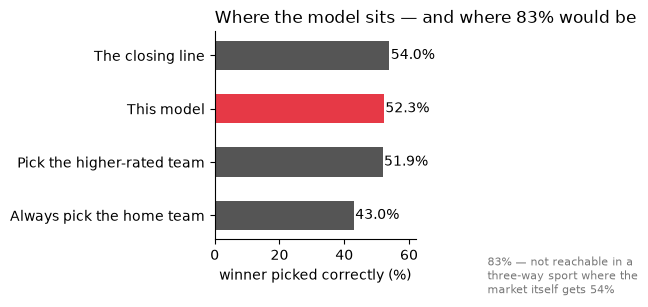

In [2]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 3.2))
lab = [e['label'] for e in ladder['ladder'] if e['accuracy'] is not None]
val = [e['accuracy'] * 100 for e in ladder['ladder'] if e['accuracy'] is not None]
colors = ['#555' if 'This model' not in l else '#e63946' for l in lab]
bars = ax.barh(lab, val, color=colors, height=0.55)
for b, v in zip(bars, val):
    ax.text(v + 0.4, b.get_y() + b.get_height()/2, f'{v:.1f}%', va='center', fontsize=10)
ax.set_xlim(0, 62)
ax.axvline(83, color='#999', ls=':', lw=1)
ax.text(83, -0.75, ' 83% — not reachable in a\n three-way sport where the\n market itself gets 54%',
        fontsize=8, color='#777', va='top')
ax.set_xlabel('winner picked correctly (%)')
ax.set_title('Where the model sits — and where 83% would be', loc='left')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

## 2. The features

Pi-ratings (Constantinou & Fenton 2013), built strictly forward — a match
updates the ratings only *after* its features are recorded — plus ClubElo read
as of the last publication before kickoff.

In [3]:
import sqlite3
from backend.scripts.benchmark_pi_ratings import load_matches, build_pi_features, WAVE_A

conn = sqlite3.connect(f"file:{ROOT}/backend/data/warehouse.sqlite?mode=ro", uri=True)
conn.row_factory = sqlite3.Row
rows = load_matches(conn, WAVE_A)
X, y, _ = build_pi_features(rows)
print(f"{len(rows):,} completed Wave A matches, {X.shape[1]} rating features")

names = ['pi_home_at_home','pi_home_away','pi_away_at_home','pi_away_away',
         'pi_matchup','pi_home_mean','pi_away_mean','pi_expected_gd']
pd.DataFrame(X, columns=names).describe().T[['mean','std','min','max']].round(3)

38,693 completed Wave A matches, 8 rating features


,mean,std,min,max
pi_home_at_home,0.389,0.555,-0.898,2.747
pi_home_away,0.113,0.493,-1.031,2.140
pi_away_at_home,0.390,0.554,-0.874,2.745
pi_away_away,0.114,0.492,-1.049,2.112
pi_matchup,0.275,0.739,-2.321,3.471
pi_home_mean,0.251,0.516,-0.876,2.441
pi_away_mean,0.252,0.516,-0.845,2.404
pi_expected_gd,0.275,0.739,-2.321,3.471


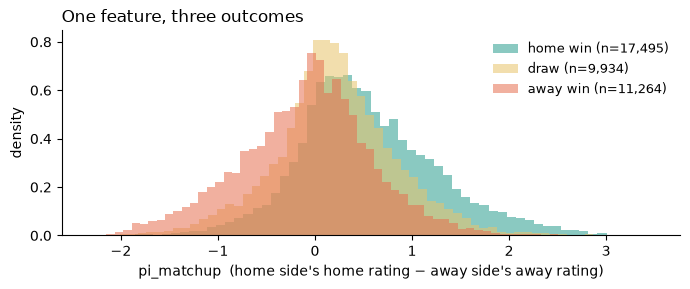

  mean pi_matchup on home win : +0.545
  mean pi_matchup on draw     : +0.216
  mean pi_matchup on away win : -0.092


In [4]:
# Does the headline feature separate the three outcomes at all?
fig, ax = plt.subplots(figsize=(7, 3))
for k, lab_, c in [(0,'home win','#2a9d8f'), (1,'draw','#e9c46a'), (2,'away win','#e76f51')]:
    ax.hist(X[y==k, 4], bins=60, alpha=.55, label=f'{lab_} (n={(y==k).sum():,})',
            density=True, color=c)
ax.set_xlabel("pi_matchup  (home side's home rating − away side's away rating)")
ax.set_ylabel('density'); ax.legend(frameon=False, fontsize=9)
ax.set_title('One feature, three outcomes', loc='left')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

for k, lab_ in [(0,'home win'),(1,'draw'),(2,'away win')]:
    print(f"  mean pi_matchup on {lab_:<9}: {X[y==k,4].mean():+.3f}")

## 3. The sweep

Sixteen configurations across HistGradientBoosting, RandomForest and XGBoost.

**The guard matters more than the grid.** Searching many configurations and
reporting the winner is how a sweep manufactures a result — with enough
candidates, something wins on noise. So the search runs on *selection* seasons
only, and the winner is scored once on *final* seasons it was never chosen on.
The gap between those two numbers is the cost of the search.

In [5]:
sweep = json.loads((ROOT / 'backend/data/diagnostics/classifier_sweep.json').read_text())
cand = pd.DataFrame(sweep['candidates']).sort_values('selection_brier')
best = sweep['best']
print(f"selection seasons {sweep['method']['selection_seasons']}  ->  "
      f"final holdout {sweep['method']['final_seasons']} (never searched on)\n")
print(f"best config        : {best['config']}")
print(f"  selection Brier  : {best['selection_brier']:.5f}")
print(f"  FINAL Brier      : {best['final_brier']:.5f}   accuracy {best['final_accuracy']:.1%}")
print(f"  cost of the search: {best['search_cost_brier']:+.5f}")
cand.head(16)

selection seasons [2018, 2019, 2020, 2021, 2022, 2023]  ->  final holdout [2024, 2025] (never searched on)

best config        : hgb_lr0.03_d3
  selection Brier  : 0.59044
  FINAL Brier      : 0.59116   accuracy 51.9%
  cost of the search: +0.00072


,config,selection_brier,selection_accuracy,n
0,hgb_lr0.03_d3,0.59044,0.5223,10781
1,hgb_lr0.06_d3,0.59061,0.5220,10781
2,hgb_lr0.03_d4,0.59079,0.5217,10781
3,hgb_lr0.12_d3,0.59095,0.5210,10781
4,hgb_lr0.06_d4,0.59109,0.5221,10781
5,xgb_lr0.03_d3,0.59109,0.5203,10781
6,rf_n600_leaf60,0.59159,0.5205,10781
7,rf_n300_leaf60,0.59175,0.5206,10781
8,hgb_lr0.12_d4,0.59176,0.5224,10781
9,hgb_lr0.03_d6,0.59179,0.5215,10781


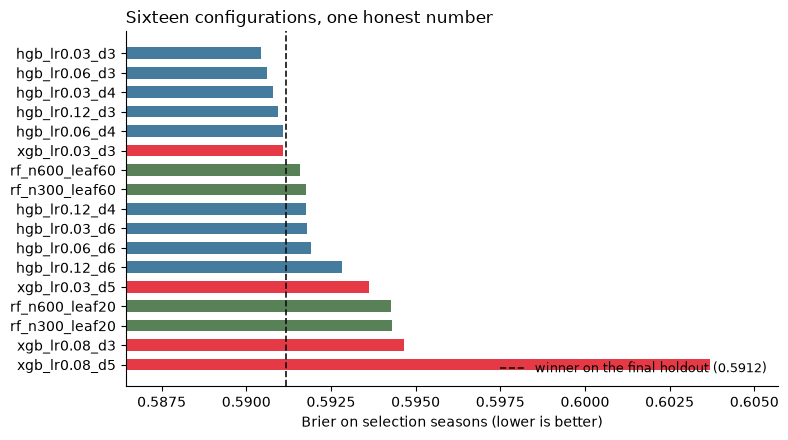

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
c = cand.sort_values('selection_brier', ascending=False)
fam = ['#457b9d' if n.startswith('hgb') else '#e63946' if n.startswith('xgb') else '#588157'
       for n in c['config']]
ax.barh(c['config'], c['selection_brier'], color=fam, height=.6)
ax.set_xlim(min(c['selection_brier'])-0.004, max(c['selection_brier'])+0.002)
ax.axvline(best['final_brier'], color='#111', ls='--', lw=1.2,
           label=f"winner on the final holdout ({best['final_brier']:.4f})")
ax.set_xlabel('Brier on selection seasons (lower is better)')
ax.set_title('Sixteen configurations, one honest number', loc='left')
ax.legend(frameon=False, fontsize=9, loc='lower right')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 4. What the trees actually leaned on

Permutation importance on held-out seasons, not gini on the training data. Gini
importance is biased toward high-cardinality continuous features and is measured
where the model was fitted, so it reports what a tree *used* rather than what
actually helps out of sample. With correlated rating features that is a
meaningful difference.

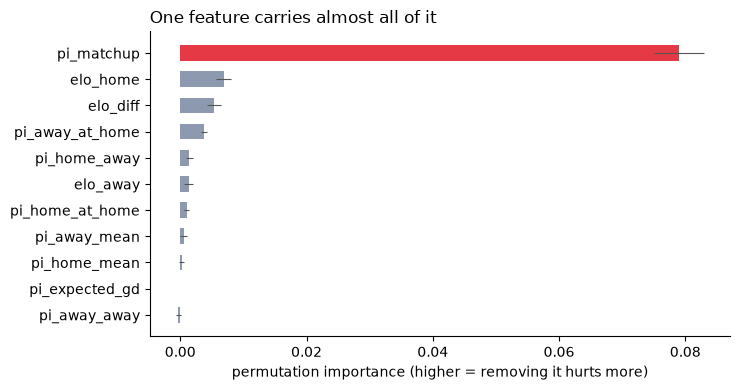

,feature,importance,std
0,pi_matchup,0.07896,0.00394
1,elo_home,0.00686,0.00124
2,elo_diff,0.00534,0.00118
3,pi_away_at_home,0.00383,0.00048
4,pi_home_away,0.00144,0.00060
5,elo_away,0.00133,0.00072
6,pi_home_at_home,0.00099,0.00045
7,pi_away_mean,0.00052,0.00057
8,pi_home_mean,0.00022,0.00036
9,pi_expected_gd,0.00000,0.00000


In [7]:
imp = pd.DataFrame(sweep['permutation_importance'])
fig, ax = plt.subplots(figsize=(7.5, 4))
i = imp.sort_values('importance')
ax.barh(i['feature'], i['importance'], xerr=i['std'],
        color=['#e63946' if v == i['importance'].max() else '#8d99ae' for v in i['importance']],
        height=.6, error_kw=dict(lw=.8, ecolor='#555'))
ax.set_xlabel('permutation importance (higher = removing it hurts more)')
ax.set_title('One feature carries almost all of it', loc='left')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()
imp

`pi_matchup` dominates by an order of magnitude, and `pi_expected_gd` scores
exactly zero — it is an algebraic duplicate of `pi_matchup` (penaltyblog defines
expected goal difference as the home side's home rating minus the away side's
away rating), so permuting one copy changes nothing while the other still
carries the signal.

That is the finding worth taking away: **the signal in this feature set is
essentially one number.** Ten more rating features buy nothing measurable, which
is exactly why six goal models, two Bayesian models, pi-ratings and sixteen tree
configurations all land within .003 Brier of each other.

## 5. An actual tree

One tree from the forest, depth-limited so it is legible. This is the "visualise
the trees" step — useful less as a model artifact than as a sanity check that
the splits are on the features and thresholds you would expect.

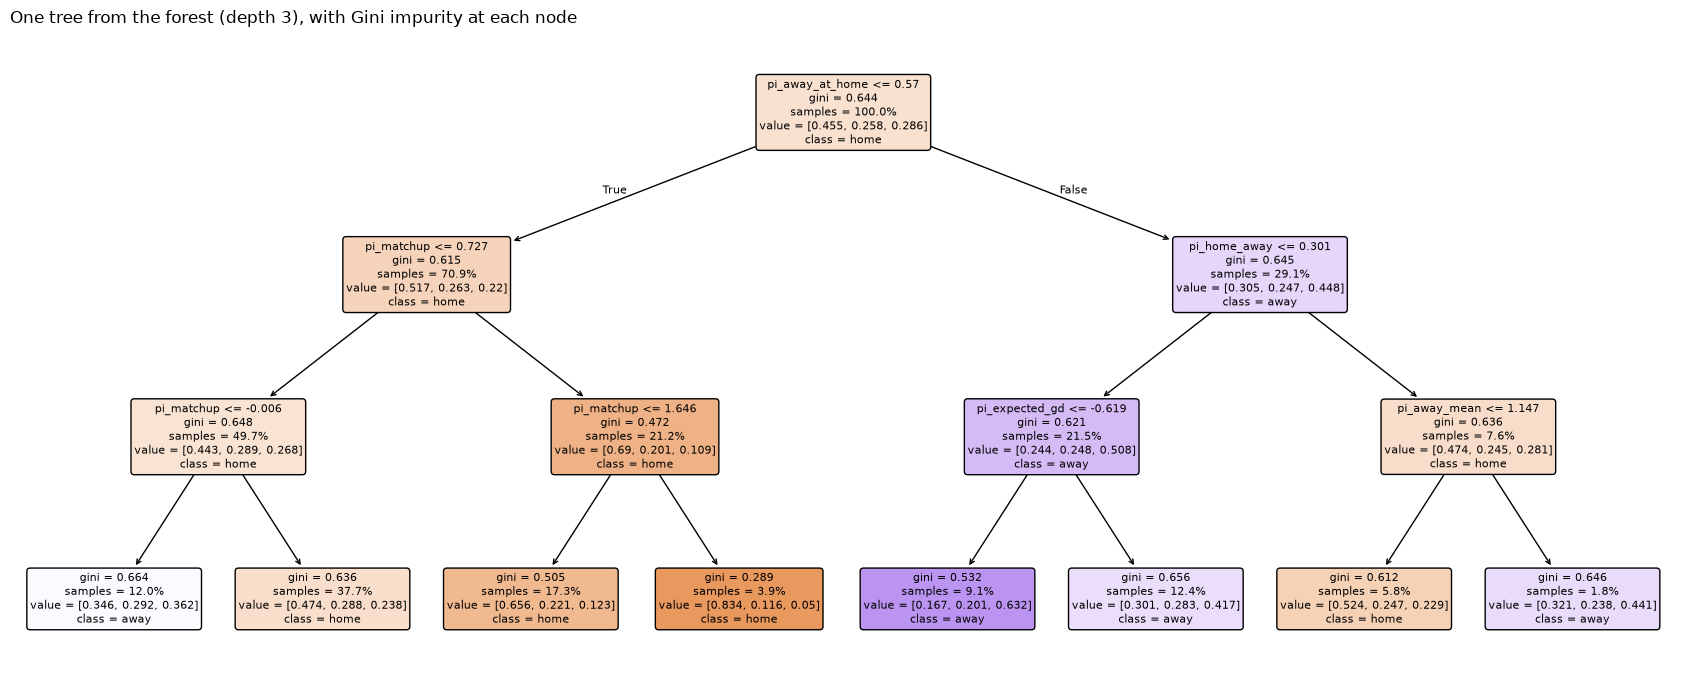

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
import numpy as np

seasons = np.array([int(r['season'] or 0) for r in rows])
tr = np.flatnonzero(seasons < 2024)
rf = RandomForestClassifier(n_estimators=200, min_samples_leaf=60, max_depth=3,
                            n_jobs=-1, random_state=17).fit(X[tr], y[tr])

fig, ax = plt.subplots(figsize=(17, 7))
plot_tree(rf.estimators_[0], feature_names=names, class_names=['home','draw','away'],
          filled=True, rounded=True, fontsize=8, impurity=True, proportion=True, ax=ax)
ax.set_title('One tree from the forest (depth 3), with Gini impurity at each node', loc='left')
plt.tight_layout(); plt.show()

## 6. Calibration — the part that is actually good

The pick is barely better than picking the higher-rated side. The *probability*
is the product: when the model says 70%, it happens about 70% of the time.

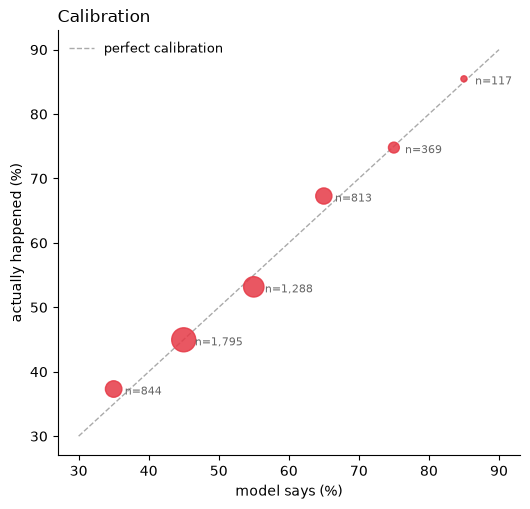

,stated_low,stated_high,n,observed
0,30,40,844,0.3732
1,40,50,1795,0.4496
2,50,60,1288,0.5318
3,60,70,813,0.6728
4,70,80,369,0.7480
5,80,90,117,0.8547


In [9]:
cal = pd.DataFrame(ladder['calibration'])
cal['stated_mid'] = (cal['stated_low'] + cal['stated_high']) / 2

fig, ax = plt.subplots(figsize=(5.4, 5.2))
ax.plot([30, 90], [30, 90], ls='--', color='#aaa', lw=1, label='perfect calibration')
ax.scatter(cal['stated_mid'], cal['observed'] * 100,
           s=cal['n'] / 6, color='#e63946', zorder=3, alpha=.85)
for _, r in cal.iterrows():
    ax.annotate(f"n={int(r['n']):,}", (r['stated_mid'], r['observed'] * 100),
                textcoords='offset points', xytext=(8, -4), fontsize=8, color='#666')
ax.set_xlabel('model says (%)'); ax.set_ylabel('actually happened (%)')
ax.set_title('Calibration', loc='left'); ax.legend(frameon=False, fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()
cal[['stated_low','stated_high','n','observed']]

## 7. Verdict

| challenger | Brier | vs Dixon-Coles |
|---|---|---|
| Dixon-Coles (serving) | .5879 | — |
| pi-ratings + gradient boosting | .5882 | +.0003, not significant |
| best of 16 swept tree configs | see above | no better |
| six penaltyblog goal models | within .003 of each other | — |
| Bayesian / hierarchical Bayesian | within .001 | — |

Five independent attempts, one answer: **the model family is not the
bottleneck.** The sweep's own importances say why — the feature set collapses to
roughly one number, and no classifier extracts more signal than the number
contains.

The two things being added now are the ones that are genuinely new information
rather than new arithmetic on the same information: **starting lineups** (which
the closing line prices within minutes of team news, and which this project had
zero rows of) and **line movement** (opening price versus close, which makes
closing line value measurable for the first time).